In [114]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

online_retail = fetch_ucirepo(id=352)
df = online_retail.data.features

df.head()

,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


Data wrangling and simple EDA 

In [115]:
df.shape

(541909, 6)

In [116]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Description  540455 non-null  object 
 1   Quantity     541909 non-null  int64  
 2   InvoiceDate  541909 non-null  object 
 3   UnitPrice    541909 non-null  float64
 4   CustomerID   406829 non-null  float64
 5   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(3)
memory usage: 24.8+ MB


In [117]:
df.isnull().any()

Description     True
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID      True
Country        False
dtype: bool

In [118]:
df_clean = df.replace(0, np.nan)

df_clean= df_clean.dropna().reset_index(drop= True)
df_clean.isnull().any()

Description    False
Quantity       False
InvoiceDate    False
UnitPrice      False
CustomerID     False
Country        False
dtype: bool

In [119]:
#Checking for any returns within the dataset
df_returns = df_clean[df_clean['UnitPrice']<= 0]

print(f'The dataset has {len(df_returns)} returns present.')

The dataset has 0 returns present.


In [120]:
df_clean.dtypes

Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

In [121]:
df_clean = df_clean.astype({'InvoiceDate': 'datetime64[ns]', 'Quantity': 'int64', 'UnitPrice': 'float64', 'CustomerID': 'int64'})

In [122]:
df_clean.dtypes

Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID              int64
Country                object
dtype: object

In [123]:
# Building RFM metrics for customer segmentation

snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'Quantity': 'nunique',
    'UnitPrice': 'sum'
    
})
rfm.rename(columns={'InvoiceDate': 'Recency', 'Quantity': 'Frequency', 'UnitPrice': 'Monetary'}, inplace=True)

In [124]:
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,2,2.08
12347,2,15,481.21
12348,75,10,178.71
12349,19,12,605.10
12350,310,5,65.30


EDA

In [139]:
rfm.describe()

,Recency,Frequency,Monetary
count,4371.000000,4371.000000,4371.000000
mean,92.064974,10.772821,322.081895
std,100.770046,7.189959,1284.920855
min,1.000000,1.000000,0.170000
25%,17.000000,6.000000,52.945000
50%,50.000000,9.000000,130.150000
75%,143.000000,14.000000,302.555000
max,374.000000,107.000000,41376.330000


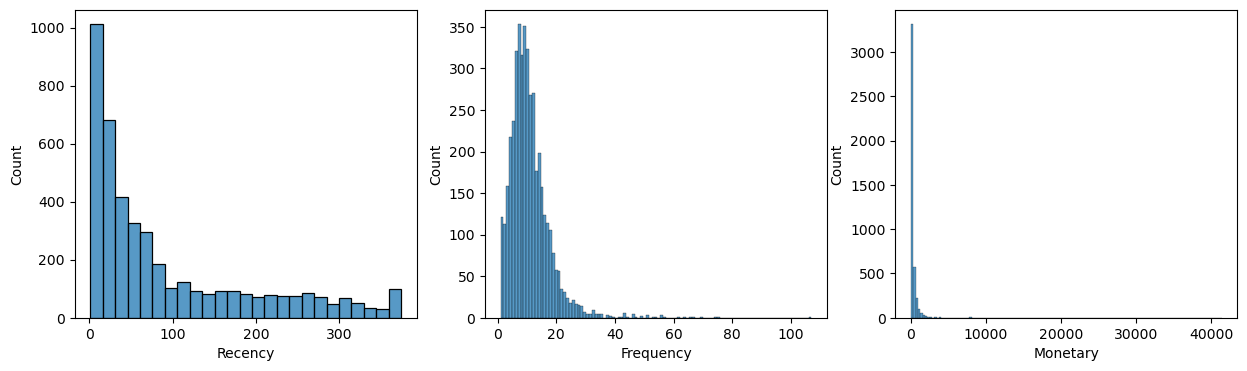

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], ax=axes[0])
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(rfm['Recency'], ax=axes[0])
sns.histplot(rfm['Frequency'], ax=axes[1])
sns.histplot(np.log1p(rfm['Monetary']), ax=axes[2], bins=50)
axes[2].set_title('Monetary (log1p)')
axes[2].set_xlabel('log1p(Monetary)')

plt.show()
sns.histplot(rfm['Monetary'], ax=axes[2])

plt.show()

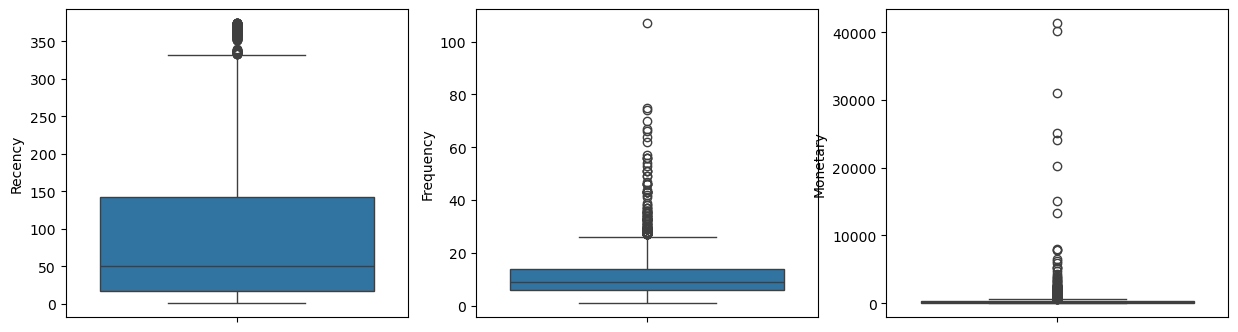

In [144]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(rfm['Recency'], ax=axes[0])
sns.boxplot(rfm['Frequency'], ax=axes[1])
sns.boxplot(rfm['Monetary'], ax=axes[2])

plt.show()